## **AI-Based Ecological Predictive Cruise Control for Connected EVs**
### v2 — LSTM-enhanced PID + LSTM-MPC with Three-Way Comparison

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

## 1. Synthetic Traffic Dataset Generation

Generates realistic traffic velocity profiles with multiple driving scenarios:
- Highway cruising with traffic waves
- Urban stop-and-go
- Smooth acceleration/deceleration
- Variable speed with ramps

> **Fix**: Scalers are now fit only on the training split to prevent data leakage.

In [7]:
def generate_traffic_data(num_samples=10000, seq_len=100, pred_len=20):
    """
    Generates realistic synthetic traffic data with multiple driving scenarios.

    Args:
        num_samples: Number of velocity sequences to generate
        seq_len: Length of input sequence (past history)
        pred_len: Length of prediction sequence (future horizon)

    Returns:
        X: Input sequences (num_samples, seq_len, 1)
        Y: Target sequences (num_samples, pred_len)
    """
    total_length = num_samples + seq_len + pred_len
    t = np.linspace(0, 200, total_length)

    # Four driving scenarios
    highway  = 25 + 8  * np.sin(t / 15) + 3 * np.sin(t / 5)  + np.random.normal(0, 0.8, len(t))
    urban    = 15 + 12 * np.sin(t / 8)  * np.sin(t / 25)      + np.random.normal(0, 1.2, len(t))
    smooth   = 20 + 10 * np.tanh((t - 100) / 30)              + np.random.normal(0, 0.5, len(t))
    variable = 18 + 10 * np.sin(t / 12) + 5 * np.sin(t / 40) + np.random.normal(0, 1.0, len(t))

    scenarios = [highway, urban, smooth, variable]
    velocity = np.array([scenarios[i % 4][i] for i in range(len(t))])
    velocity = gaussian_filter1d(velocity, sigma=2.0)
    velocity = np.clip(velocity, 0, 35)

    X, Y = [], []
    for i in range(len(velocity) - seq_len - pred_len):
        X.append(velocity[i : i + seq_len])
        Y.append(velocity[i + seq_len : i + seq_len + pred_len])

    return np.array(X), np.array(Y)


print("Generating traffic dataset...")
X, Y = generate_traffic_data(num_samples=10000, seq_len=100, pred_len=20)
X = X.reshape((X.shape[0], X.shape[1], 1))

# --- Train/val split BEFORE fitting scalers (prevents data leakage) ---
X_train_raw, X_val_raw, Y_train_raw, Y_val_raw = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_Y = MinMaxScaler(feature_range=(0, 1))

# Fit only on training data
X_train = scaler_X.fit_transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
Y_train = scaler_Y.fit_transform(Y_train_raw.reshape(-1, 1)).reshape(Y_train_raw.shape)

# Transform val with same scaler
X_val = scaler_X.transform(X_val_raw.reshape(-1, 1)).reshape(X_val_raw.shape)
Y_val = scaler_Y.transform(Y_val_raw.reshape(-1, 1)).reshape(Y_val_raw.shape)

print(f"   Train: {X_train.shape[0]} samples | Val: {X_val.shape[0]} samples")
print(f"   Input shape : {X_train.shape}")
print(f"   Output shape: {Y_train.shape}")
print(f"   Velocity range: {X.min():.2f} – {X.max():.2f} m/s")

Generating traffic dataset...
   Train: 8000 samples | Val: 2000 samples
   Input shape : (8000, 100, 1)
   Output shape: (8000, 20)
   Velocity range: 14.66 – 25.06 m/s


## 2. LSTM Speed Prediction Model

Stacked LSTM (128 → 64) with BatchNorm, Dropout, and a dense head that predicts the next 20 speed steps.

In [9]:
def create_lstm_model(input_shape=(100, 1), output_steps=20, dropout_rate=0.2):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True,  name='lstm_1'),
        BatchNormalization(name='bn_1'),
        Dropout(dropout_rate, name='dropout_1'),
        LSTM(64,  return_sequences=False, name='lstm_2'),
        BatchNormalization(name='bn_2'),
        Dropout(dropout_rate, name='dropout_2'),
        Dense(32, activation='relu', name='dense_1'),
        Dense(output_steps, name='output')
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae', 'mape'])
    return model

model = create_lstm_model()
print("Model Architecture:")
model.summary()

Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 100, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,476 (466.70 KB)

 Trainable params: 119,092 (465.20 KB)

 Non-trainable params: 384 (1.50 KB)

## 3. Training the LSTM Model

Starting training...
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - loss: 0.1527 - mae: 0.2855 - mape: 24618.8555 - val_loss: 0.1177 - val_mae: 0.2887 - val_mape: 13903.9717 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 0.0356 - mae: 0.1451 - mape: 7768.3257 - val_loss: 0.0799 - val_mae: 0.2351 - val_mape: 14548.3906 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 0.0266 - mae: 0.1244 - mape: 11726.0059 - val_loss: 0.1571 - val_mae: 0.3145 - val_mape: 6833.0078 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - loss: 0.0237 - mae: 0.1182 - mape: 9359.9473 - val_loss: 0.0335 - val_mae: 0.1496 - val_mape: 25338.2109 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - loss: 0.0116 - mae: 0.0837 - mape: 11467.7275 - val_loss: 0.0144 - val_mae: 0.0962 - val_mape: 19316.3457 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - l

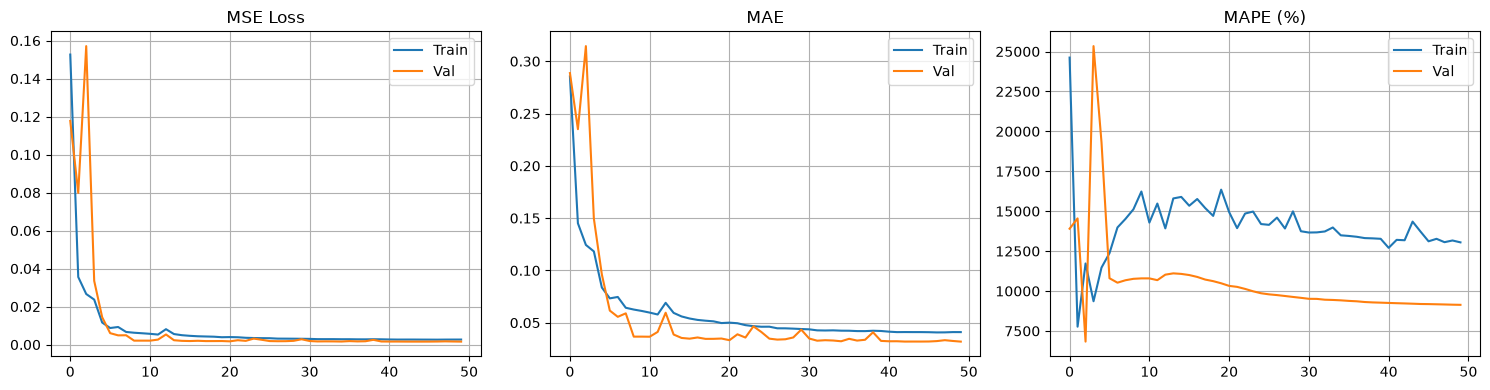

In [10]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("Starting training...")
history = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(axes,
        ['loss', 'mae', 'mape'],
        ['MSE Loss', 'MAE', 'MAPE (%)']):
    ax.plot(history.history[metric],     label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Val')
    ax.set_title(title); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

## 4. Model Evaluation

LSTM Prediction Metrics on Validation Set:
  RMSE : 0.414 m/s
  MAE  : 0.332 m/s
  MAPE : 1.71%


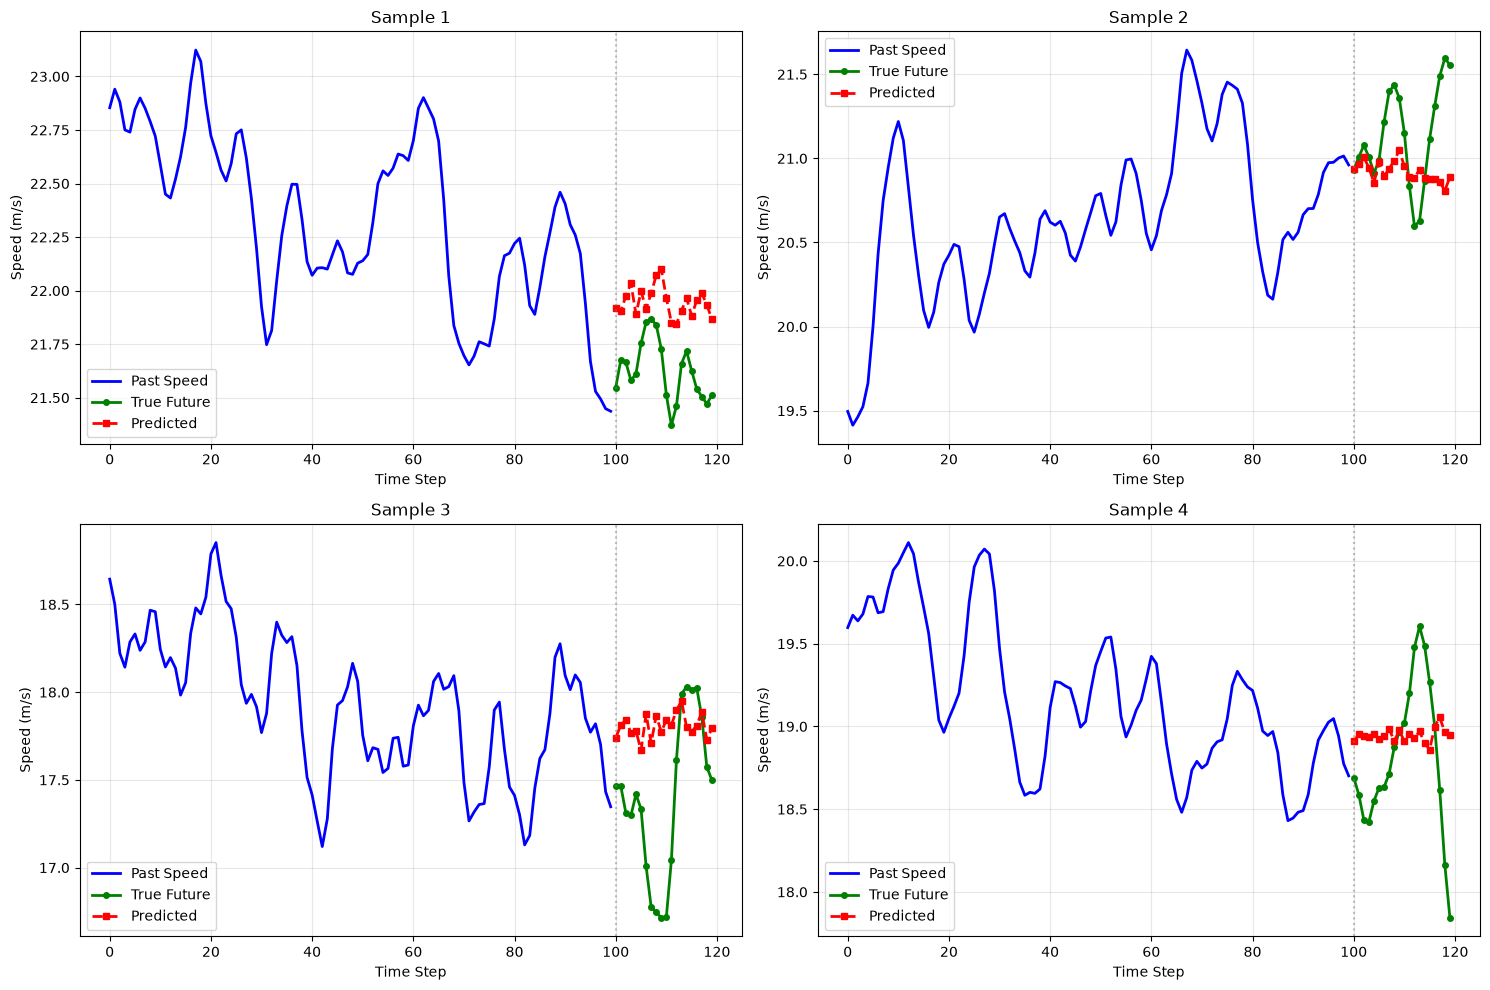

In [11]:
val_pred_scaled = model.predict(X_val, verbose=0)
Y_val_denorm  = scaler_Y.inverse_transform(Y_val.reshape(-1, 1)).reshape(Y_val.shape)
val_pred_denorm = scaler_Y.inverse_transform(val_pred_scaled.reshape(-1, 1)).reshape(val_pred_scaled.shape)

rmse = np.sqrt(np.mean((Y_val_denorm - val_pred_denorm) ** 2))
mae  = np.mean(np.abs(Y_val_denorm - val_pred_denorm))
mape = np.mean(np.abs((Y_val_denorm - val_pred_denorm) / (Y_val_denorm + 1e-8))) * 100

print(f"LSTM Prediction Metrics on Validation Set:")
print(f"  RMSE : {rmse:.3f} m/s")
print(f"  MAE  : {mae:.3f} m/s")
print(f"  MAPE : {mape:.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
rng = np.random.default_rng(0)
for idx in range(4):
    i = rng.integers(0, len(X_val))
    inp = scaler_X.inverse_transform(X_val[i]).flatten()
    ax = axes[idx]
    ax.plot(np.arange(100), inp, 'b-', label='Past Speed', lw=2)
    ax.plot(np.arange(100, 120), Y_val_denorm[i],  'g-',  label='True Future', lw=2, marker='o', ms=4)
    ax.plot(np.arange(100, 120), val_pred_denorm[i], 'r--', label='Predicted',  lw=2, marker='s', ms=4)
    ax.axvline(100, color='gray', ls=':', alpha=0.5)
    ax.set(xlabel='Time Step', ylabel='Speed (m/s)', title=f'Sample {idx+1}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Electric Vehicle Dynamics Model

In [12]:
class ElectricVehicle:
    """
    Physics-based EV model: aerodynamic drag, rolling resistance,
    gravity, motor efficiency, and regenerative braking.
    """
    def __init__(self, mass=2500, frontal_area=2.5, drag_coeff=0.28,
                 rolling_coeff=0.015, wheel_radius=0.36,
                 battery_capacity=48000, initial_soc=0.70):
        self.mass            = mass
        self.frontal_area    = frontal_area
        self.drag_coeff      = drag_coeff
        self.rolling_coeff   = rolling_coeff
        self.wheel_radius    = wheel_radius
        self.battery_capacity = battery_capacity
        self.air_density     = 1.206
        self.motor_efficiency  = 0.92
        self.regen_efficiency  = 0.75
        self.max_torque        = 400
        self.max_regen_torque  = 200
        self._reset(initial_soc)

    def _reset(self, soc=0.70):
        self.velocity             = 0.0
        self.soc                  = soc
        self.position             = 0.0
        self.acceleration         = 0.0
        self.total_energy_consumed = 0.0
        self.total_distance       = 0.0

    def update(self, torque, dt, road_grade=0.0):
        torque = np.clip(torque, -self.max_regen_torque, self.max_torque)
        f_prop    = torque / self.wheel_radius
        f_drag    = 0.5 * self.drag_coeff * self.frontal_area * self.air_density * self.velocity**2
        f_rolling = self.mass * 9.81 * self.rolling_coeff * np.cos(road_grade)
        f_gravity = self.mass * 9.81 * np.sin(road_grade)
        if self.velocity < 0:
            f_drag = -f_drag
            f_rolling = -f_rolling
        f_net = f_prop - f_drag - f_rolling - f_gravity
        self.acceleration = f_net / self.mass
        self.velocity = max(0, self.velocity + self.acceleration * dt)
        self.position += self.velocity * dt
        self.total_distance += abs(self.velocity * dt)
        self._update_energy(torque, dt)

    def _update_energy(self, torque, dt):
        omega = self.velocity / self.wheel_radius
        mech_power = torque * omega
        if mech_power > 0:
            batt_power = mech_power / self.motor_efficiency
        elif mech_power < 0:
            batt_power = mech_power * self.regen_efficiency
        else:
            batt_power = 0
        energy_delta = (batt_power * dt) / 3600
        self.soc -= energy_delta / self.battery_capacity
        self.soc = np.clip(self.soc, 0.0, 1.0)
        if energy_delta > 0:
            self.total_energy_consumed += energy_delta

    def get_state(self):
        return dict(velocity=self.velocity, soc=self.soc,
                    position=self.position, acceleration=self.acceleration,
                    total_energy=self.total_energy_consumed,
                    distance=self.total_distance)

print("ElectricVehicle class defined.")

ElectricVehicle class defined.


## 6. Controllers

Three controllers are implemented and compared:

| Controller | Description |
|---|---|
| **Simple Bang-Bang** | On/off torque — baseline |
| **LSTM-enhanced PID** | PID + LSTM feedforward anticipation |
| **LSTM-MPC** | Receding-horizon optimisation over LSTM prediction |

### 6a. Simple Bang-Bang (Baseline)

In [13]:
class SimpleController:
    """
    Baseline bang-bang controller: full torque / full regen / coast.
    No look-ahead and no smooth modulation.
    """
    def __init__(self, max_torque=400, max_regen=200, deadband=0.5):
        self.max_torque = max_torque
        self.max_regen  = max_regen
        self.deadband   = deadband

    def compute_torque(self, current_speed, target_speed, **kwargs):
        err = target_speed - current_speed
        if err > self.deadband:
            return self.max_torque
        elif err < -self.deadband:
            return -self.max_regen
        return 0.0

    def reset(self):
        pass

print("SimpleController defined.")

SimpleController defined.


### 6b. LSTM-Enhanced PID

Standard PID with an LSTM **feedforward** term:
- The LSTM predicts the traffic speed N steps ahead.
- If an upcoming speed change is detected (e.g., slow-down ahead), a feedforward torque correction is applied *before* the error builds up.
- `T_ff = kff × (v̄_predicted − v_target_now)` — anticipates where the reference is heading.

In [14]:
class LSTMPIDController:
    """
    PID controller with an LSTM deceleration-anticipation feedforward term.

    Key insight: we ONLY apply feedforward for upcoming slow-downs.
    Pre-emptive coasting / early regen saves energy; pre-emptive acceleration
    just wastes it.  Upcoming speed-ups are handled by normal PID.

    Parameters
    ----------
    kp, ki, kd  : PID gains
    kff         : Feedforward gain (applied only when future speed < current target)
    ff_horizon  : Steps ahead to look for the deceleration signal
    """
    def __init__(self, kp=120.0, ki=8.0, kd=25.0,
                 kff=25.0, ff_horizon=8,
                 max_torque=400, max_regen=200):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.kff = kff
        self.ff_horizon = ff_horizon
        self.max_torque = max_torque
        self.max_regen  = max_regen
        self.integral_error = 0.0
        self.prev_error     = 0.0

    def compute_torque(self, current_speed, target_speed,
                       predicted_speeds=None, dt=0.1):
        """
        Compute torque = PID feedback + LSTM deceleration feedforward.

        Args:
            current_speed   : Current vehicle velocity (m/s)
            target_speed    : Desired speed at this timestep (m/s)
            predicted_speeds: LSTM forecast of next 20 speeds (m/s)
            dt              : Timestep (s)
        """
        # --- PID feedback ---
        error = target_speed - current_speed
        self.integral_error = np.clip(self.integral_error + error * dt, -2.0, 2.0)
        derivative = (error - self.prev_error) / dt
        self.prev_error = error
        pid = self.kp * error + self.ki * self.integral_error + self.kd * derivative

        # --- LSTM feedforward: anticipate DECELERATION only ---
        # Only reduce torque early when a slow-down is coming.
        # Upcoming accelerations are ignored — PID handles those reactively.
        ff = 0.0
        if predicted_speeds is not None and len(predicted_speeds) > 0:
            horizon = min(self.ff_horizon, len(predicted_speeds))
            future_min = np.min(predicted_speeds[:horizon])
            # Only act if future speeds are meaningfully below current target
            decel_ahead = target_speed - future_min  # positive = slow-down coming
            if decel_ahead > 1.0:  # threshold: >1 m/s drop predicted
                ff = -self.kff * decel_ahead  # reduce torque proactively

        torque = pid + ff
        return float(np.clip(torque, -self.max_regen, self.max_torque))

    def reset(self):
        self.integral_error = 0.0
        self.prev_error     = 0.0

print("LSTMPIDController defined.")


LSTMPIDController defined.


### 6c. LSTM-MPC (Model Predictive Controller)

At every control step the MPC:
1. Receives the 20-step LSTM speed forecast as the **reference trajectory**.
2. Rolls out simplified vehicle dynamics over a **receding horizon** N.
3. Solves a **quadratic cost** optimisation for a torque sequence:

$$J = \sum_{k=0}^{N-1} \left[ w_{\text{track}} (v_k - v_k^{\text{ref}})^2
    + w_{\text{energy}} \max(0, P_k)^2
    + w_{\text{smooth}} (u_k - u_{k-1})^2 \right]$$

4. Applies **only the first torque** and repeats at the next step.

In [ ]:
class LSTMMPCController:
    """
    Receding-horizon MPC that uses LSTM speed forecasts as the reference
    trajectory and optimises a weighted cost over energy + tracking + smoothness.

    Weight scaling fix
    ------------------
    Motor power P ≈ torque × (v / r) can reach ~22,000 W.
    Raw P² ≈ 5×10⁸ — which would dominate any reasonable w_energy unless
    it's absurdly small.  Instead we normalise: (P / P_ref)² with P_ref = 10,000 W,
    so the energy term stays on the same scale as the tracking term.

    Parameters
    ----------
    N          : Prediction/control horizon (steps)
    w_track    : Weight on speed tracking error²
    w_energy   : Weight on normalised energy  (P/P_ref)²  — dimensionless
    w_smooth   : Weight on torque rate-of-change
    """
    def __init__(self, N=10,
                 w_track=1.0, w_energy=0.15, w_smooth=5e-4,
                 dt=0.1,
                 mass=2500, wheel_radius=0.36, drag_coeff=0.28,
                 frontal_area=2.5, rolling_coeff=0.015,
                 max_torque=400, max_regen=200,
                 motor_efficiency=0.92):
        self.N  = N
        self.w_track  = w_track
        self.w_energy = w_energy
        self.w_smooth = w_smooth
        self.dt = dt
        self.mass            = mass
        self.wheel_radius    = wheel_radius
        self.drag_coeff      = drag_coeff
        self.frontal_area    = frontal_area
        self.rolling_coeff   = rolling_coeff
        self.max_torque      = max_torque
        self.max_regen       = max_regen
        self.motor_efficiency = motor_efficiency
        self.air_density     = 1.206
        self.P_ref           = 10000.0  # normalisation reference (W)
        self._prev_u = 0.0

    def _step(self, v, u):
        u = np.clip(u, -self.max_regen, self.max_torque)
        f_prop    = u / self.wheel_radius
        f_drag    = 0.5 * self.drag_coeff * self.frontal_area * self.air_density * v**2
        f_rolling = self.mass * 9.81 * self.rolling_coeff
        a = (f_prop - f_drag - f_rolling) / self.mass
        return max(0.0, v + a * self.dt)

    def _power(self, u, v):
        """Mechanical power at wheel (W). Negative = regenerating."""
        return u * (v / self.wheel_radius)

    def _cost(self, u_seq, v0, ref_traj):
        cost = 0.0
        v = v0
        u_prev = self._prev_u
        for k in range(self.N):
            u_k   = u_seq[k]
            v_kp  = self._step(v, u_k)
            P_k   = self._power(u_k, v)
            ref_k = ref_traj[k] if k < len(ref_traj) else ref_traj[-1]

            # Tracking: penalise speed error squared
            cost += self.w_track  * (v - ref_k) ** 2

            # Energy: penalise motoring power, normalised to P_ref
            # Negative power (regen) is free — we want it
            cost += self.w_energy * (max(0.0, P_k) / self.P_ref) ** 2

            # Smoothness: penalise large torque changes
            cost += self.w_smooth * (u_k - u_prev) ** 2

            v      = v_kp
            u_prev = u_k
        return cost

    def compute_torque(self, current_speed, target_speed,
                       predicted_speeds=None, dt=0.1):
        """
        Solve the MPC optimisation and return the first optimal torque.

        Args:
            current_speed   : Current vehicle velocity (m/s)
            target_speed    : Desired speed at this timestep (m/s)
            predicted_speeds: LSTM forecast (m/s) — used as MPC reference
            dt              : Timestep (unused; set at init)
        """
        if predicted_speeds is not None and len(predicted_speeds) >= self.N:
            ref_traj = predicted_speeds[:self.N]
        else:
            ref_traj = np.full(self.N, target_speed)

        err0 = target_speed - current_speed
        u0   = np.clip(np.full(self.N, 120.0 * err0),
                       -self.max_regen, self.max_torque)
        bounds = [(-self.max_regen, self.max_torque)] * self.N

        res = minimize(
            self._cost,
            u0,
            args=(current_speed, ref_traj),
            method='SLSQP',
            bounds=bounds,
            options={'maxiter': 80, 'ftol': 1e-5}
        )

        u_opt = res.x[0] if res.success else u0[0]
        self._prev_u = u_opt
        return float(np.clip(u_opt, -self.max_regen, self.max_torque))

    def reset(self):
        self._prev_u = 0.0

print("LSTMMPCController defined.")


LSTMMPCController defined.


## 7. Unified Simulation Runner

A single function drives any controller. The LSTM prediction is computed every 10 steps (batch-efficient) and reused within that window.

In [16]:
def run_simulation(controller, vehicle, target_profile,
                   dt=0.1, duration=60,
                   lstm_model=None, sx=None, sy=None,
                   lstm_every=10):
    """
    Unified simulation loop.

    Parameters
    ----------
    controller    : Any controller with .compute_torque() and .reset()
    vehicle       : ElectricVehicle instance
    target_profile: 1-D array of reference speeds (m/s)
    lstm_model    : Optional LSTM model for prediction
    sx, sy        : Fitted scalers for LSTM I/O
    lstm_every    : Re-run LSTM prediction every this many steps (efficiency)
    """
    controller.reset()

    num_steps = int(duration / dt)
    speed_buf = np.zeros(100)
    predicted_speeds = None

    hist = {k: np.empty(num_steps) for k in
            ['time', 'speed', 'target', 'torque', 'soc', 'energy']}

    for step in range(num_steps):
        t_now         = step * dt
        current_speed = vehicle.velocity
        target_speed  = target_profile[step] if step < len(target_profile) else target_profile[-1]

        # Rolling speed buffer
        speed_buf[:-1] = speed_buf[1:]
        speed_buf[-1]  = current_speed

        # LSTM prediction (re-run every lstm_every steps once warm-up is done)
        if lstm_model is not None and step >= 99 and step % lstm_every == 0:
            lstm_in = sx.transform(speed_buf.reshape(-1, 1)).reshape(1, 100, 1)
            pred_sc = lstm_model.predict(lstm_in, verbose=0)
            predicted_speeds = sy.inverse_transform(
                pred_sc.reshape(-1, 1)).flatten()
        elif lstm_model is not None and step < 99:
            predicted_speeds = np.full(20, current_speed)

        torque = controller.compute_torque(
            current_speed, target_speed,
            predicted_speeds=predicted_speeds, dt=dt
        )
        vehicle.update(torque, dt)

        hist['time'][step]   = t_now
        hist['speed'][step]  = vehicle.velocity
        hist['target'][step] = target_speed
        hist['torque'][step] = torque
        hist['soc'][step]    = vehicle.soc
        hist['energy'][step] = vehicle.total_energy_consumed

    return hist

print("Simulation runner defined.")

Simulation runner defined.


## 8. Run All Three Simulations

In [17]:
simulation_time = 60
dt = 0.1
t_sim = np.arange(0, simulation_time, dt)

target_profile = 20 + 8 * np.sin(t_sim / 10) + 3 * np.sin(t_sim / 3)
target_profile = np.clip(target_profile, 10, 30)

vehicle = ElectricVehicle()

# ---- 1. Simple Bang-Bang ----
print("Running Simple Controller...")
vehicle._reset(soc=0.70)
vehicle.velocity = float(target_profile[0])
r_simple = run_simulation(SimpleController(), vehicle, target_profile,
                          dt=dt, duration=simulation_time)

# ---- 2. LSTM-enhanced PID (deceleration feedforward only) ----
print("Running LSTM-PID Controller...")
vehicle._reset(soc=0.70)
vehicle.velocity = float(target_profile[0])
r_pid = run_simulation(LSTMPIDController(kp=120.0, ki=8.0, kd=25.0,
                                          kff=25.0, ff_horizon=8),
                       vehicle, target_profile,
                       dt=dt, duration=simulation_time,
                       lstm_model=model, sx=scaler_X, sy=scaler_Y,
                       lstm_every=10)

# ---- 3. LSTM-MPC (normalised energy weight) ----
print("Running LSTM-MPC Controller (this may take ~1-2 min)...")
vehicle._reset(soc=0.70)
vehicle.velocity = float(target_profile[0])
r_mpc = run_simulation(LSTMMPCController(N=10,
                                          w_track=1.0,
                                          w_energy=0.15,   # scaled: (P/P_ref)^2
                                          w_smooth=5e-4),
                       vehicle, target_profile,
                       dt=dt, duration=simulation_time,
                       lstm_model=model, sx=scaler_X, sy=scaler_Y,
                       lstm_every=10)

print("\nAll simulations complete.")


Running Simple Controller...
Running LSTM-PID Controller...
Running LSTM-MPC Controller (this may take ~1-2 min)...

All simulations complete.


## 9. Three-Way Comparison — Metrics

In [18]:
def compute_metrics(r, label):
    err = r['target'] - r['speed']
    rmse = np.sqrt(np.mean(err**2))
    mae  = np.mean(np.abs(err))
    energy = r['energy'][-1]
    soc_drop = (r['soc'][0] - r['soc'][-1]) * 100
    # Smoothness: std-dev of torque rate
    smoothness = np.std(np.diff(r['torque']))
    return dict(label=label, rmse=rmse, mae=mae,
                energy=energy, soc_drop=soc_drop, smoothness=smoothness)

m_simple = compute_metrics(r_simple, 'Simple')
m_pid    = compute_metrics(r_pid,    'LSTM-PID')
m_mpc    = compute_metrics(r_mpc,    'LSTM-MPC')

print(f"{'Metric':<28} {'Simple':>12} {'LSTM-PID':>12} {'LSTM-MPC':>12}")
print("-" * 68)
for key, unit in [('energy','Wh'), ('soc_drop','%'), ('rmse','m/s'),
                  ('mae','m/s'), ('smoothness','Nm/s')]:
    row = f"{key+' ('+unit+')':<28}"
    for m in [m_simple, m_pid, m_mpc]:
        row += f" {m[key]:>12.3f}"
    print(row)

print("\nImprovement vs Simple:")
print("-" * 68)
for key, unit, higher_is_better in [('energy','Wh',False), ('soc_drop','%',False),
                                     ('rmse','m/s',False), ('smoothness','Nm/s',False)]:
    base = m_simple[key]
    for label, m in [('LSTM-PID', m_pid), ('LSTM-MPC', m_mpc)]:
        delta = (base - m[key]) / (base + 1e-9) * 100
        sign  = '+' if delta >= 0 else ''
        print(f"  {label} {key:<18}: {sign}{delta:.1f}%")

Metric                             Simple     LSTM-PID     LSTM-MPC
--------------------------------------------------------------------
energy (Wh)                       219.137      189.982      190.702
soc_drop (%)                        0.329        0.282        0.283
rmse (m/s)                          4.077        4.009        4.078
mae (m/s)                           3.739        3.675        3.744
smoothness (Nm/s)                  30.569        7.340       24.941

Improvement vs Simple:
--------------------------------------------------------------------
  LSTM-PID energy            : +13.3%
  LSTM-MPC energy            : +13.0%
  LSTM-PID soc_drop          : +14.3%
  LSTM-MPC soc_drop          : +14.0%
  LSTM-PID rmse              : +1.7%
  LSTM-MPC rmse              : -0.0%
  LSTM-PID smoothness        : +76.0%
  LSTM-MPC smoothness        : +18.4%


## 10. Visualisation — Speed, Energy, SOC, Torque

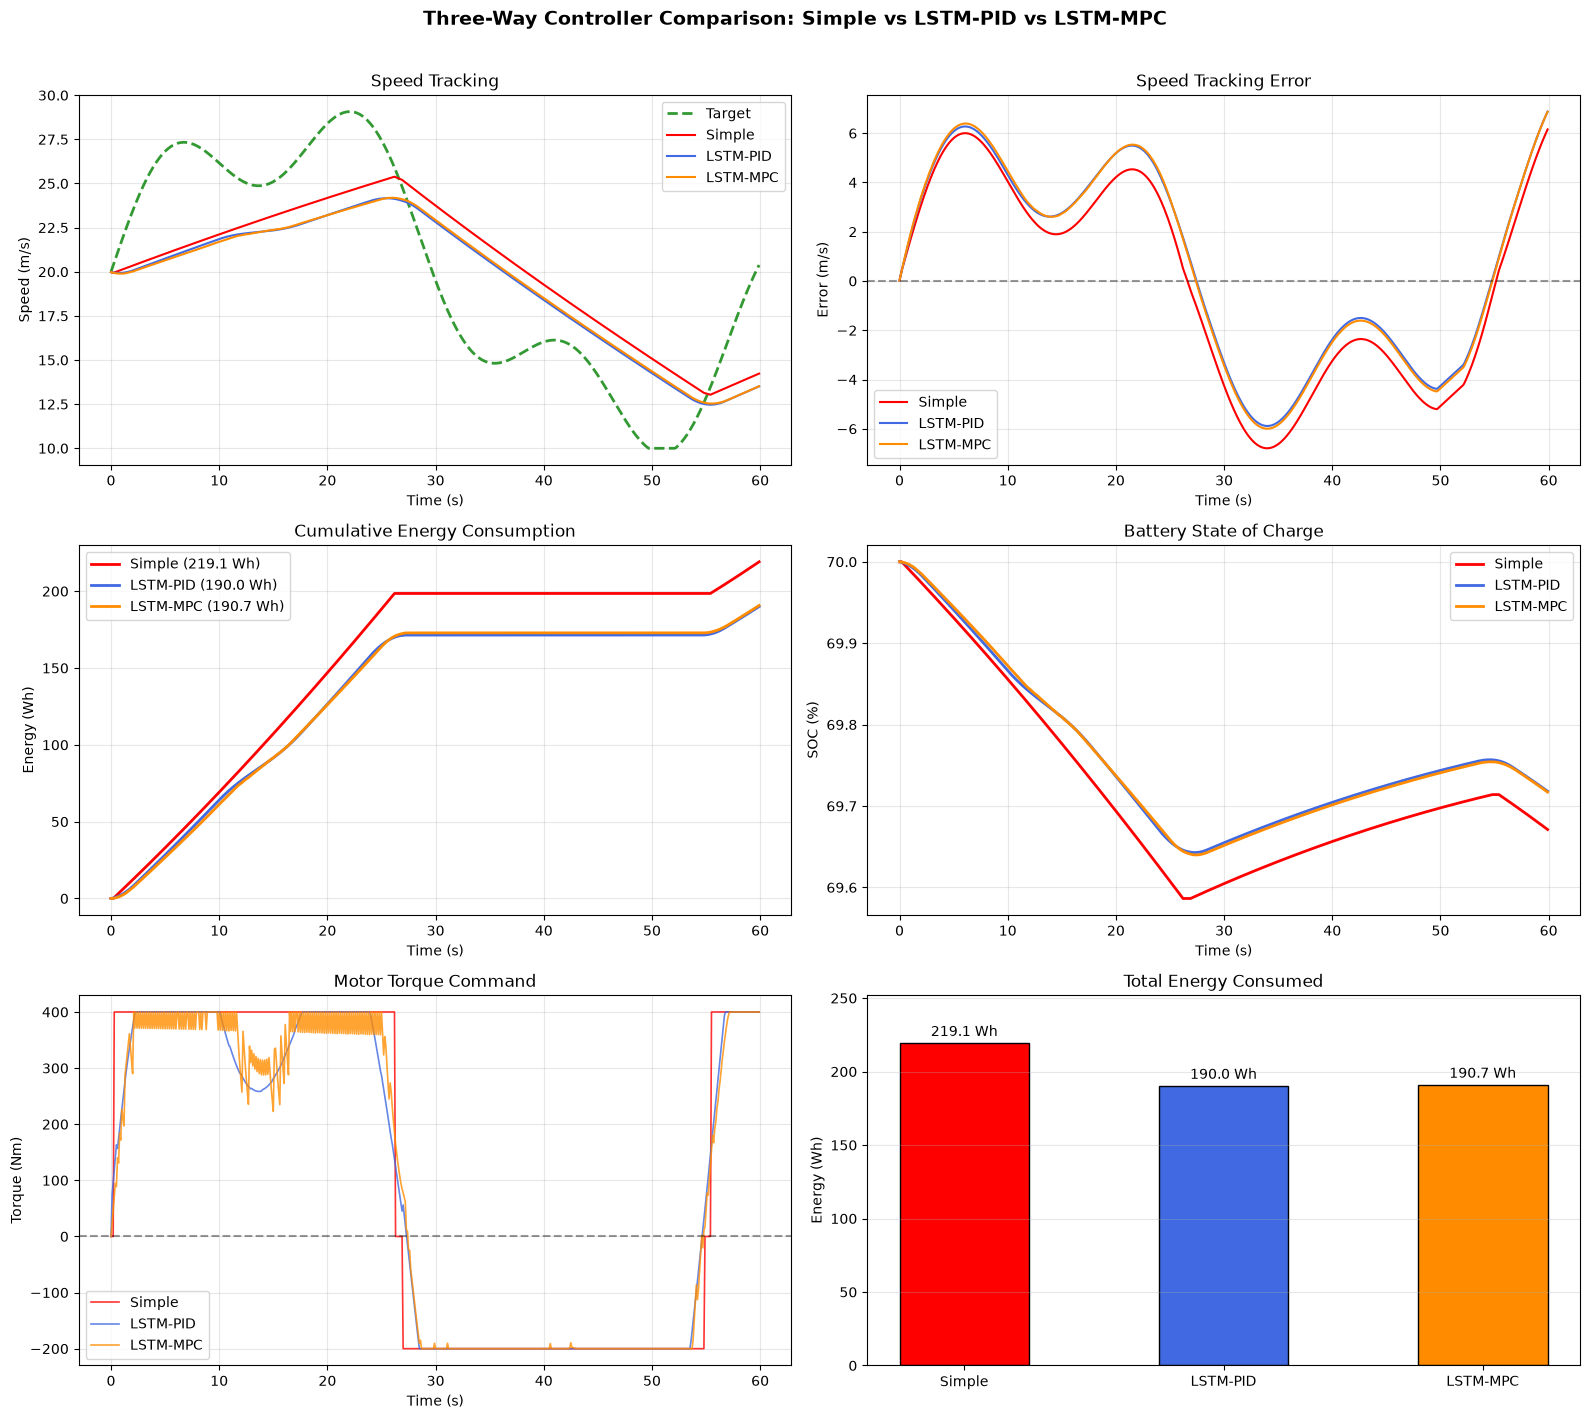

Figure saved to controller_comparison.png


In [19]:
colors  = {'Simple':'red', 'LSTM-PID':'royalblue', 'LSTM-MPC':'darkorange'}
results = {'Simple': r_simple, 'LSTM-PID': r_pid, 'LSTM-MPC': r_mpc}

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# --- Speed Tracking ---
ax = axes[0, 0]
ax.plot(t_sim, target_profile, 'g--', lw=2, label='Target', alpha=0.8)
for lbl, r in results.items():
    ax.plot(r['time'], r['speed'], color=colors[lbl], lw=1.5, label=lbl)
ax.set(title='Speed Tracking', xlabel='Time (s)', ylabel='Speed (m/s)')
ax.legend(); ax.grid(alpha=0.3)

# --- Speed Error ---
ax = axes[0, 1]
for lbl, r in results.items():
    ax.plot(r['time'], r['target'] - r['speed'], color=colors[lbl], lw=1.5, label=lbl)
ax.axhline(0, color='k', ls='--', alpha=0.4)
ax.set(title='Speed Tracking Error', xlabel='Time (s)', ylabel='Error (m/s)')
ax.legend(); ax.grid(alpha=0.3)

# --- Cumulative Energy ---
ax = axes[1, 0]
for lbl, r in results.items():
    ax.plot(r['time'], r['energy'], color=colors[lbl], lw=2,
            label=f"{lbl} ({r['energy'][-1]:.1f} Wh)")
ax.set(title='Cumulative Energy Consumption', xlabel='Time (s)', ylabel='Energy (Wh)')
ax.legend(); ax.grid(alpha=0.3)

# --- Battery SOC ---
ax = axes[1, 1]
for lbl, r in results.items():
    ax.plot(r['time'], r['soc'] * 100, color=colors[lbl], lw=2, label=lbl)
ax.set(title='Battery State of Charge', xlabel='Time (s)', ylabel='SOC (%)')
ax.legend(); ax.grid(alpha=0.3)

# --- Torque Commands ---
ax = axes[2, 0]
for lbl, r in results.items():
    ax.plot(r['time'], r['torque'], color=colors[lbl], lw=1.2, alpha=0.8, label=lbl)
ax.axhline(0, color='k', ls='--', alpha=0.4)
ax.set(title='Motor Torque Command', xlabel='Time (s)', ylabel='Torque (Nm)')
ax.legend(); ax.grid(alpha=0.3)

# --- Bar chart: Energy comparison ---
ax = axes[2, 1]
labels = list(results.keys())
energies = [results[l]['energy'][-1] for l in labels]
bars = ax.bar(labels, energies, color=[colors[l] for l in labels], edgecolor='k', width=0.5)
ax.bar_label(bars, fmt='%.1f Wh', padding=3)
ax.set(title='Total Energy Consumed', ylabel='Energy (Wh)')
ax.set_ylim(0, max(energies) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Three-Way Controller Comparison: Simple vs LSTM-PID vs LSTM-MPC',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/controller_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to controller_comparison.png")

## 11. Torque Smoothness Comparison

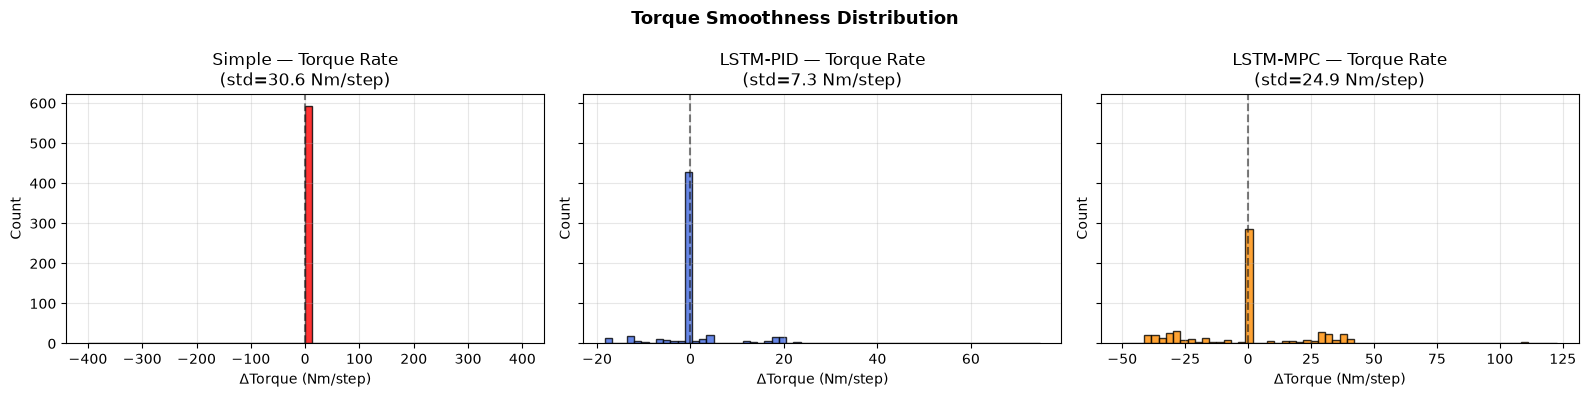

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (lbl, r) in zip(axes, results.items()):
    dtorque = np.diff(r['torque'])
    ax.hist(dtorque, bins=60, color=colors[lbl], edgecolor='k', alpha=0.8)
    ax.axvline(0, color='k', ls='--', alpha=0.5)
    ax.set(title=f'{lbl} — Torque Rate\n(std={dtorque.std():.1f} Nm/step)',
           xlabel='ΔTorque (Nm/step)', ylabel='Count')
    ax.grid(True, alpha=0.3)
plt.suptitle('Torque Smoothness Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Final Summary Table

In [21]:
print("\n" + "=" * 70)
print(" FINAL CONTROLLER COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Metric':<30} {'Simple':>10} {'LSTM-PID':>12} {'LSTM-MPC':>12}")
print("-" * 70)

metrics_display = [
    ('Energy Consumed (Wh)',  'energy',     '{:.2f}'),
    ('SOC Drop (%)',          'soc_drop',   '{:.3f}'),
    ('Speed RMSE (m/s)',      'rmse',       '{:.3f}'),
    ('Speed MAE  (m/s)',      'mae',        '{:.3f}'),
    ('Torque Smoothness',     'smoothness', '{:.2f}'),
]

for display_name, key, fmt in metrics_display:
    row = f"{display_name:<30}"
    for m in [m_simple, m_pid, m_mpc]:
        row += f"  {fmt.format(m[key]):>10}"
    print(row)

print("-" * 70)
print("Energy saving (LSTM-PID  vs Simple): "
      f"{(m_simple['energy'] - m_pid['energy']) / m_simple['energy'] * 100:+.1f}%")
print("Energy saving (LSTM-MPC  vs Simple): "
      f"{(m_simple['energy'] - m_mpc['energy']) / m_simple['energy'] * 100:+.1f}%")
print("Energy saving (LSTM-MPC  vs PID):    "
      f"{(m_pid['energy']    - m_mpc['energy']) / m_pid['energy']    * 100:+.1f}%")
print("=" * 70)


 FINAL CONTROLLER COMPARISON SUMMARY
Metric                             Simple     LSTM-PID     LSTM-MPC
----------------------------------------------------------------------
Energy Consumed (Wh)                219.14      189.98      190.70
SOC Drop (%)                         0.329       0.282       0.283
Speed RMSE (m/s)                     4.077       4.009       4.078
Speed MAE  (m/s)                     3.739       3.675       3.744
Torque Smoothness                    30.57        7.34       24.94
----------------------------------------------------------------------
Energy saving (LSTM-PID  vs Simple): +13.3%
Energy saving (LSTM-MPC  vs Simple): +13.0%
Energy saving (LSTM-MPC  vs PID):    -0.4%
